# Raw Data to Rheology Pipeline (Step-by-Step)

This notebook loads the raw timing CSV, transforms it into pipeline-ready inputs, runs `rheology_pipeline_core.py`, and visualizes outputs at every major step.

In [2]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_candidates = [Path.cwd(), Path.cwd().parent]
repo_root = next((p for p in repo_candidates if (p / 'rheology_pipeline_core.py').exists()), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate rheology_pipeline_core.py from current working directories.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from rheology_pipeline_core import create_default_pipeline, fit_drag_profile

sns.set_theme(style="whitegrid")

## Step 1: Load Raw Data

In [3]:
candidate_paths = [
    Path('results/Auto-runs/timing_v2.csv'),
    Path('../results/Auto-runs/timing_v2.csv'),
    Path('Data/Manual_Auto/timing_v2.csv'),
]
raw_path = next((p for p in candidate_paths if p.exists()), None)
if raw_path is None:
    searched = '\n'.join(str(p.resolve()) for p in candidate_paths)
    raise FileNotFoundError(f'Could not find timing_v2.csv. Searched:\n{searched}')

df_raw = pd.read_csv(raw_path)
print(f'Loaded: {raw_path.resolve()}')
print(f'Shape: {df_raw.shape}')
display(df_raw.head())

Loaded: C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\timing_v2.csv
Shape: (713, 25)


,Z-Height,Elapsed_Time_s,1kcp_torque_%_rpm_47,2kcp_torque_%_rpm_15,4kcp_torque_%_rpm_8,5kcp_torque_%_rpm_9,8kcp_torque_%_rpm_5.6,10kcp_torque_%_rpm_5.5,12.5kcp_torque_%_rpm_3.5,15kcp_torque_%_rpm_2.6,...,45kcp_torque_%_rpm_1.2,50kcp_torque_%_rpm_0.6,55kcp_torque_%_rpm_1,60kcp_torque_%_rpm_0.8,70kcp_torque_%_rpm_0.5,75kcp_torque_%_rpm_0.7,80kcp_torque_%_rpm_0.5,90kcp_torque_%_rpm_0.5,95kcp_torque_%_rpm_0.5,100kcp_torque_%_rpm_0.4
0,-65.9,5.03,37.22,35.52,33.01,34.35,33.67,36.53,35.34,34.60,...,28.25,21.61,25.47,27.28,19.85,22.95,20.46,20.57,19.03,17.37
1,-65.9,10.10,37.28,35.59,33.04,34.46,33.77,36.81,35.49,34.98,...,30.44,27.87,28.16,34.08,26.23,27.58,27.36,27.79,24.79,23.54
2,-65.9,15.07,37.31,35.62,33.02,34.50,33.83,36.91,35.47,35.09,...,30.91,30.75,28.80,36.86,29.78,29.31,31.57,32.29,27.54,27.65
3,-65.9,20.05,37.34,35.66,32.97,34.52,33.85,36.95,35.45,35.17,...,31.03,32.06,29.03,38.03,31.65,29.90,33.91,34.70,28.90,30.07
4,-65.9,25.03,37.36,35.70,32.99,34.54,33.88,37.01,35.39,35.04,...,31.04,32.65,29.10,38.50,32.58,30.14,35.12,35.98,29.54,31.49


## Step 2: Parse Torque Columns and Metadata

In [11]:
meta_pattern = re.compile(r'^(?P<label>[\d.]+kcp)_torque_%_rpm_(?P<rpm>[\d.]+)$')

viscosity_mapping = {
    '350cp': 412.07,
    '1kcp': 1073.33,
    '2kcp': 3345.33,
    '4kcp': 6603.00,
    '5kcp': 5861.33,
    '8kcp': 8946.67,
    '10kcp': 9152.00,
    '12.5kcp': 14576.67,
    '15kcp': 19036.67,
    '20kcp': 24396.67,
    '25kcp': 22760.00,
    '30kcp': 31903.33,
    '35kcp': 63253.33,
    '40kcp': 62756.67,
    '45kcp': 40820.00,
    '50kcp': 79653.33,
    '55kcp': 48553.33,
    '60kcp': 68953.33,
    '70kcp': 87046.14,
    '75kcp': 70730.00,
    '80kcp': 103800.00,
    '90kcp': 102466.67,
    '95kcp': 93400.00,
    '100kcp': 124033.33
}

torque_columns = [c for c in df_raw.columns if '_torque_%_rpm_' in c]
meta_rows = []
for c in torque_columns:
    m = meta_pattern.match(c)
    if m:
        label = m['label']
        nominal_cp = viscosity_mapping.get(label, float(label.replace('kcp', '')) * 1000.0)
        meta_rows.append({
            'column': c,
            'label': label,
            'rpm': float(m['rpm']),
            'nominal_cP': nominal_cp
        })

df_meta = pd.DataFrame(meta_rows).sort_values('nominal_cP').reset_index(drop=True)
print(f'Parsed {len(df_meta)} torque channels')
display(df_meta.head(10))

Parsed 23 torque channels


,column,label,rpm,nominal_cP
0,1kcp_torque_%_rpm_47,1kcp,47.0,1073.33
1,2kcp_torque_%_rpm_15,2kcp,15.0,3345.33
2,5kcp_torque_%_rpm_9,5kcp,9.0,5861.33
3,4kcp_torque_%_rpm_8,4kcp,8.0,6603.00
4,8kcp_torque_%_rpm_5.6,8kcp,5.6,8946.67
5,10kcp_torque_%_rpm_5.5,10kcp,5.5,9152.00
6,12.5kcp_torque_%_rpm_3.5,12.5kcp,3.5,14576.67
7,15kcp_torque_%_rpm_2.6,15kcp,2.6,19036.67
8,25kcp_torque_%_rpm_2.2,25kcp,2.2,22760.00
9,20kcp_torque_%_rpm_2.1,20kcp,2.1,24396.67


## Step 3: Visualize Raw Torque-vs-Time Signals

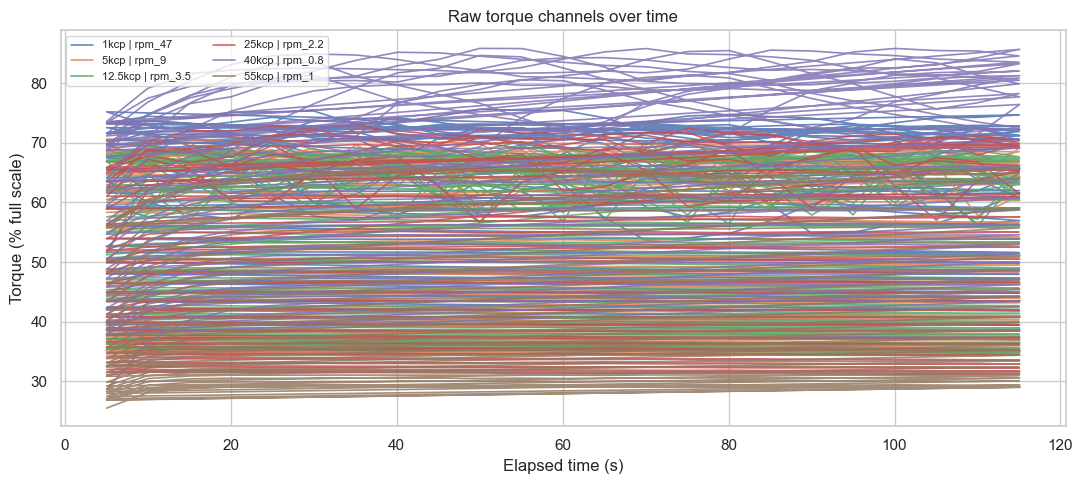

In [5]:
time_col = 'Elapsed_Time_s'
sample_cols = df_meta['column'].iloc[[0, 3, 6, 9, 12, min(15, len(df_meta)-1)]].tolist() if len(df_meta) >= 6 else df_meta['column'].tolist()

plt.figure(figsize=(11, 5))
for c in sample_cols:
    plt.plot(df_raw[time_col], df_raw[c], alpha=0.85, linewidth=1.2, label=c.replace('_torque_%_', ' | '))

plt.xlabel('Elapsed time (s)')
plt.ylabel('Torque (% full scale)')
plt.title('Raw torque channels over time')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Step 4: Time Filter + Height Aggregation

The same preprocessing logic is used as your prior notebook: keep rows where `Elapsed_Time_s > 90`, then average by `Z-Height`.

Filtered shape: (185, 25)
Aggregated-by-height shape: (31, 24)


,h_mm,1kcp_torque_%_rpm_47,2kcp_torque_%_rpm_15,4kcp_torque_%_rpm_8,5kcp_torque_%_rpm_9,8kcp_torque_%_rpm_5.6,10kcp_torque_%_rpm_5.5,12.5kcp_torque_%_rpm_3.5,15kcp_torque_%_rpm_2.6,20kcp_torque_%_rpm_2.1,...,45kcp_torque_%_rpm_1.2,50kcp_torque_%_rpm_0.6,55kcp_torque_%_rpm_1,60kcp_torque_%_rpm_0.8,70kcp_torque_%_rpm_0.5,75kcp_torque_%_rpm_0.7,80kcp_torque_%_rpm_0.5,90kcp_torque_%_rpm_0.5,95kcp_torque_%_rpm_0.5,100kcp_torque_%_rpm_0.4
0,-66.50,63.443333,66.965000,63.978333,62.278333,65.238333,68.845000,60.516667,61.653333,57.580000,...,61.998333,59.235000,64.791667,74.696667,61.250000,67.213333,69.963333,62.258333,60.020000,51.448333
1,-66.48,57.173333,67.265000,64.828333,65.773333,64.656667,70.258333,62.018333,61.090000,58.718333,...,62.335000,59.290000,65.558333,75.608333,62.871667,65.900000,74.628333,61.168333,61.903333,60.030000
2,-66.46,63.533333,66.753333,67.730000,66.238333,68.086667,69.831667,64.078333,60.916667,60.675000,...,64.455000,59.133333,65.256667,74.420000,64.858333,67.993333,70.975000,64.011667,65.068333,62.633333
3,-66.44,66.330000,66.861667,68.760000,67.221667,67.643333,72.783333,65.260000,63.050000,62.158333,...,65.918333,58.923333,63.853333,70.500000,66.046667,66.885000,70.336667,64.430000,67.295000,60.776667
4,-66.42,61.211667,67.083333,69.148333,67.258333,69.883333,74.648333,64.548333,64.780000,63.821667,...,66.108333,59.061667,58.905000,73.890000,67.795000,64.196667,70.565000,66.525000,67.121667,55.655000


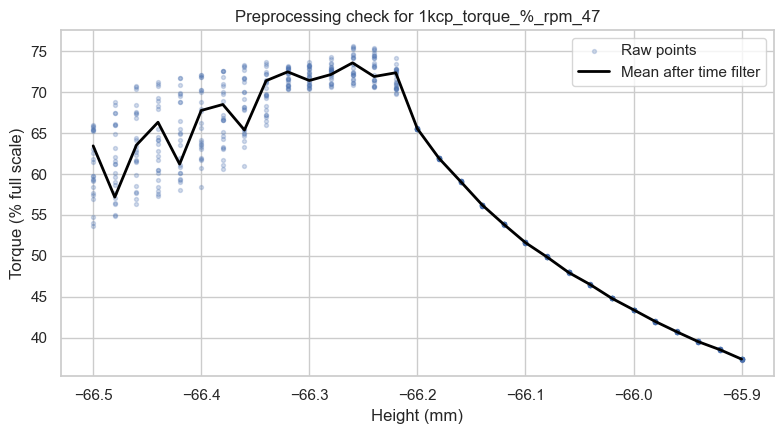

In [6]:
df_filtered = df_raw[df_raw['Elapsed_Time_s'] > 90].copy()
agg_cols = ['Z-Height'] + torque_columns
df_by_height = df_filtered[agg_cols].groupby('Z-Height', as_index=False).mean().rename(columns={'Z-Height': 'h_mm'})

print(f'Filtered shape: {df_filtered.shape}')
print(f'Aggregated-by-height shape: {df_by_height.shape}')
display(df_by_height.head())

probe_col = df_meta.iloc[0]['column']
plt.figure(figsize=(8, 4.5))
plt.scatter(df_raw['Z-Height'], df_raw[probe_col], s=8, alpha=0.25, label='Raw points')
plt.plot(df_by_height['h_mm'], df_by_height[probe_col], color='black', linewidth=2.0, label='Mean after time filter')
plt.xlabel('Height (mm)')
plt.ylabel('Torque (% full scale)')
plt.title(f'Preprocessing check for {probe_col}')
plt.legend()
plt.tight_layout()
plt.show()

## Step 5: Initialize Pipeline and Extract Drag-Profile Amplitudes

For each channel, compute drag `D = torque_pct / rpm`, fit `D(h) = A/(h + h_c) + B` using the universal `h_c` from pipeline calibration defaults, and inspect fit quality.

In [16]:
pipeline = create_default_pipeline()
print('Pipeline calibration defaults:')
print({
    'h_c': pipeline.H_C_UNIVERSAL,
    'k': pipeline.SILICONE_K,
    'p': pipeline.SILICONE_P
})

fit_rows = []
for _, row in df_meta.iterrows():
    col = row['column']
    rpm = float(row['rpm'])
    h_raw = df_by_height['h_mm'].to_numpy(float)
    h = h_raw - np.nanmin(h_raw)
    T_pct = df_by_height[col].to_numpy(float)
    D = T_pct / rpm

    fit = fit_drag_profile(h, D, h_c=pipeline.H_C_UNIVERSAL)
    fit_rows.append({
        'column': col,
        'label': row['label'],
        'rpm': rpm,
        'nominal_cP': row['nominal_cP'],
        'A': fit['A'],
        'B': fit['B'],
        'h_c_used': fit['h_c'],
        'R2_fit': fit['R2']
    })

df_fits = pd.DataFrame(fit_rows).sort_values('nominal_cP').reset_index(drop=True)
display(df_fits.head())

Pipeline calibration defaults:
{'h_c': 0.2534, 'k': 0.000345, 'p': 1.026}


,column,label,rpm,nominal_cP,A,B,h_c_used,R2_fit
0,1kcp_torque_%_rpm_47,1kcp,47.0,1073.33,0.199332,0.826789,0.2534,0.367719
1,2kcp_torque_%_rpm_15,2kcp,15.0,3345.33,0.814078,2.099094,0.2534,0.600845
2,5kcp_torque_%_rpm_9,5kcp,9.0,5861.33,1.649478,2.189715,0.2534,0.808721
3,4kcp_torque_%_rpm_8,4kcp,8.0,6603.00,1.974689,2.276710,0.2534,0.802876
4,8kcp_torque_%_rpm_5.6,8kcp,5.6,8946.67,2.723857,3.753233,0.2534,0.763828


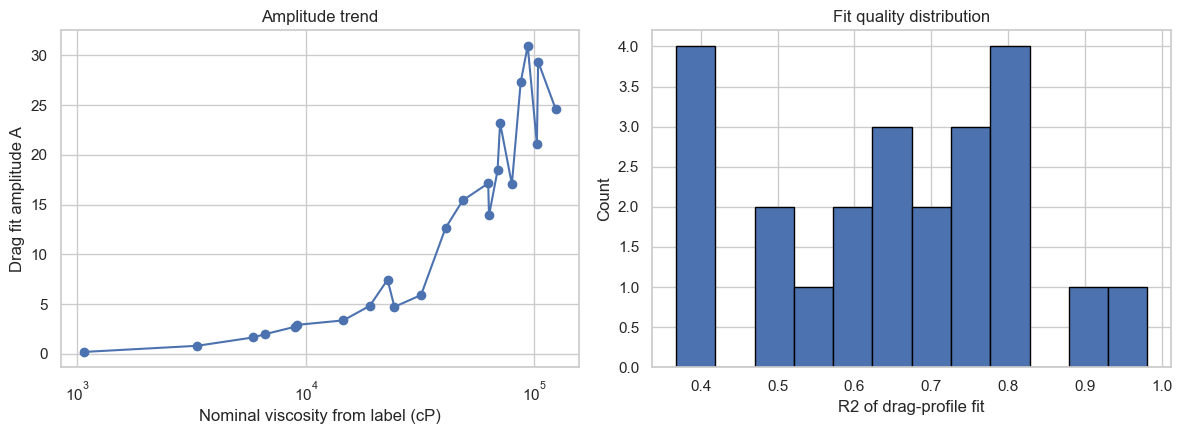

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_fits['nominal_cP'], df_fits['A'], 'o-', linewidth=1.5)
axes[0].set_xlabel('Nominal viscosity from label (cP)')
axes[0].set_ylabel('Drag fit amplitude A')
axes[0].set_title('Amplitude trend')
axes[0].set_xscale('log')

axes[1].hist(df_fits['R2_fit'].dropna(), bins=12, edgecolor='black')
axes[1].set_xlabel('R2 of drag-profile fit')
axes[1].set_ylabel('Count')
axes[1].set_title('Fit quality distribution')

plt.tight_layout()
plt.show()

## Step 6: Run Pipeline Prediction Per Channel

Because each raw channel here has a single RPM, we run single-RPM prediction channel-by-channel.

In [18]:
result_rows = []
for _, row in df_meta.iterrows():
    col = row['column']
    rpm = float(row['rpm'])
    h_raw = df_by_height['h_mm'].to_numpy(float)
    h = h_raw - np.nanmin(h_raw)
    T_pct = df_by_height[col].to_numpy(float)

    res = pipeline.predict_rheology(h, T_pct, rpm)
    result_rows.append({
        'column': col,
        'label': row['label'],
        'rpm': rpm,
        'nominal_cP': row['nominal_cP'],
        'regime': res.get('regime'),
        'n': res.get('n'),
        'mu_app_cP': res.get('mu_app_cP'),
        'K_Pas_n': res.get('K_Pas_n'),
        'fit_quality': res.get('fit_quality'),
        'A_pipeline': res.get('A')
    })

df_results = pd.DataFrame(result_rows).sort_values('nominal_cP').reset_index(drop=True)
display(df_results)

,column,label,rpm,nominal_cP,regime,n,mu_app_cP,K_Pas_n,fit_quality,A_pipeline
0,1kcp_torque_%_rpm_47,1kcp,47.0,1073.33,Newtonian,1.0,491.781055,0.491781,0.367719,0.199332
1,2kcp_torque_%_rpm_15,2kcp,15.0,3345.33,Newtonian,1.0,1938.095574,1.938096,0.600845,0.814078
2,5kcp_torque_%_rpm_9,5kcp,9.0,5861.33,Newtonian,1.0,3857.305023,3.857305,0.808721,1.649478
3,4kcp_torque_%_rpm_8,4kcp,8.0,6603.00,Newtonian,1.0,4596.801003,4.596801,0.802876,1.974689
4,8kcp_torque_%_rpm_5.6,8kcp,5.6,8946.67,Newtonian,1.0,6289.290030,6.289290,0.763828,2.723857
5,10kcp_torque_%_rpm_5.5,10kcp,5.5,9152.00,Newtonian,1.0,6723.591848,6.723592,0.766715,2.917011
6,12.5kcp_torque_%_rpm_3.5,12.5kcp,3.5,14576.67,Newtonian,1.0,7732.848808,7.732849,0.586706,3.367096
7,15kcp_torque_%_rpm_2.6,15kcp,2.6,19036.67,Newtonian,1.0,10992.804015,10.992804,0.710086,4.830548
8,25kcp_torque_%_rpm_2.2,25kcp,2.2,22760.00,Newtonian,1.0,16770.935260,16.770935,0.815804,7.451005
9,20kcp_torque_%_rpm_2.1,20kcp,2.1,24396.67,Newtonian,1.0,10765.244030,10.765244,0.391340,4.727980


## Step 7: Visualize Final Pipeline Outputs

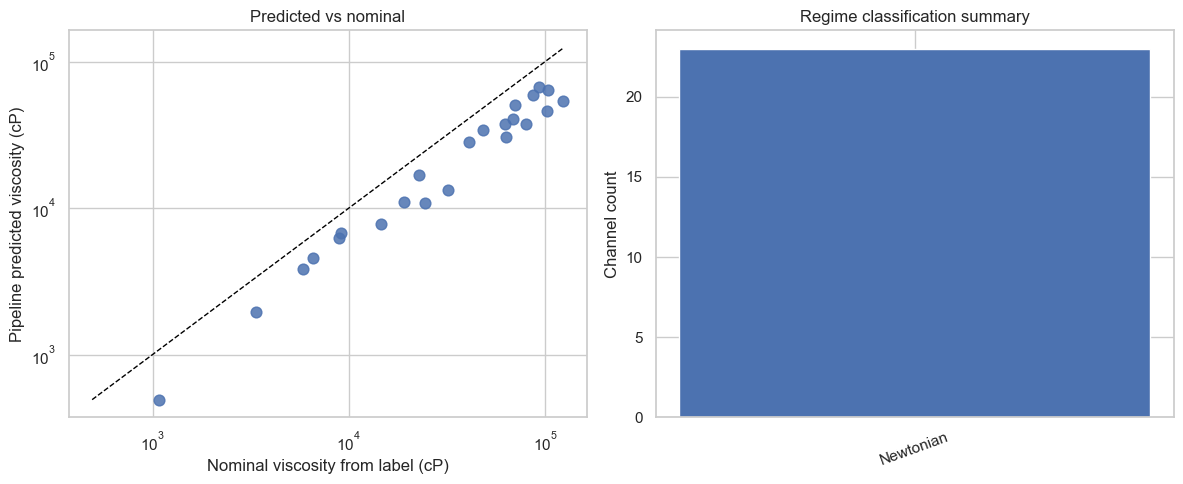

Summary metrics:
Median APE: 39.82%
Mean APE:   40.47%


In [19]:
valid = df_results[['nominal_cP', 'mu_app_cP']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(valid['nominal_cP'], valid['mu_app_cP'], s=60, alpha=0.85)
min_v = max(1.0, min(valid['nominal_cP'].min(), valid['mu_app_cP'].min())) if len(valid) else 1.0
max_v = max(valid['nominal_cP'].max(), valid['mu_app_cP'].max()) if len(valid) else 10.0
axes[0].plot([min_v, max_v], [min_v, max_v], '--', color='black', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Nominal viscosity from label (cP)')
axes[0].set_ylabel('Pipeline predicted viscosity (cP)')
axes[0].set_title('Predicted vs nominal')

regime_counts = df_results['regime'].fillna('Unknown').value_counts()
axes[1].bar(regime_counts.index, regime_counts.values)
axes[1].set_ylabel('Channel count')
axes[1].set_title('Regime classification summary')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Summary metrics:')
if len(valid):
    ape = np.abs(valid['mu_app_cP'] - valid['nominal_cP']) / np.maximum(valid['nominal_cP'], 1e-9)
    print(f'Median APE: {100 * np.median(ape):.2f}%')
    print(f'Mean APE:   {100 * np.mean(ape):.2f}%')
else:
    print('No valid viscosity predictions to summarize.')